## 1. Import Data and EDA

Descriptions of the columns are available [here](../../Data/floods_description.md)

In [1]:
import geopandas as gpd

df = gpd.read_file('../../Data/floods.gpkg')

df.head()

,ward,subcounty,county,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg,geometry
0,WABERA,Isiolo Sub County,ISIOLO,17431.0,0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,1.413028,"MULTIPOLYGON (((37.59968 0.40029, 37.59976 0.4..."
1,North Kamagambo Ward,Rongo Sub County,Migori,18755.0,0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,2.246821,"MULTIPOLYGON (((34.59938 -0.65054, 34.60006 -0..."
2,Central Kamagambo Ward,Rongo Sub County,Migori,27756.0,0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,3.392240,"MULTIPOLYGON (((34.61175 -0.73357, 34.61183 -0..."
3,South Kamagambo Ward,Rongo Sub County,Migori,27179.0,0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,4.263301,"MULTIPOLYGON (((34.61751 -0.87293, 34.6175 -0...."
4,North Sakwa Ward,Awendo Sub County,Migori,22874.0,0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,3.834336,"MULTIPOLYGON (((34.55349 -0.75193, 34.55364 -0..."


In [2]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ward                 1450 non-null   object  
 1   subcounty            1450 non-null   object  
 2   county               1450 non-null   object  
 3   pop2009              1450 non-null   float64 
 4   flooded              1450 non-null   int64   
 5   rain_cumulative_mm   1450 non-null   float64 
 6   rain_max_daily_mm    1450 non-null   float64 
 7   rain_preflood_7d_mm  1450 non-null   float64 
 8   elevation_mean_m     1450 non-null   float64 
 9   elevation_min_m      1450 non-null   float64 
 10  elevation_max_m      1450 non-null   float64 
 11  slope_mean_deg       1450 non-null   float64 
 12  geometry             1450 non-null   geometry
dtypes: float64(8), geometry(1), int64(1), object(3)
memory usage: 147.4+ KB


In [3]:
df.duplicated().sum()

np.int64(0)

## 2. Create features and target

I will engineer a new feature: `elevation_range_m`, that is the difference between the maximum (`elevation_max_m`) and minimum (`elevation_min_m`) elevations. This is important because places with steeper slopes i.e. greater elevation ranges tend to flood less compared to flat areas with lower elevation ranges.

In [4]:
df['elevation_range_m'] = df['elevation_max_m'] - df['elevation_min_m']

df.head()

,ward,subcounty,county,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg,geometry,elevation_range_m
0,WABERA,Isiolo Sub County,ISIOLO,17431.0,0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,1.413028,"MULTIPOLYGON (((37.59968 0.40029, 37.59976 0.4...",151.0
1,North Kamagambo Ward,Rongo Sub County,Migori,18755.0,0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,2.246821,"MULTIPOLYGON (((34.59938 -0.65054, 34.60006 -0...",158.0
2,Central Kamagambo Ward,Rongo Sub County,Migori,27756.0,0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,3.392240,"MULTIPOLYGON (((34.61175 -0.73357, 34.61183 -0...",147.0
3,South Kamagambo Ward,Rongo Sub County,Migori,27179.0,0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,4.263301,"MULTIPOLYGON (((34.61751 -0.87293, 34.6175 -0....",275.0
4,North Sakwa Ward,Awendo Sub County,Migori,22874.0,0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,3.834336,"MULTIPOLYGON (((34.55349 -0.75193, 34.55364 -0...",330.0


In [5]:
df.columns

Index(['ward', 'subcounty', 'county', 'pop2009', 'flooded',
       'rain_cumulative_mm', 'rain_max_daily_mm', 'rain_preflood_7d_mm',
       'elevation_mean_m', 'elevation_min_m', 'elevation_max_m',
       'slope_mean_deg', 'geometry', 'elevation_range_m'],
      dtype='object')

In [6]:
# Drop geometry and metadata columns
feature_columns = [
    'pop2009',
    'rain_cumulative_mm',
    'rain_max_daily_mm',
    'rain_preflood_7d_mm',
    'elevation_mean_m',
    'elevation_min_m',
    'elevation_max_m',
    'elevation_range_m',
    'slope_mean_deg'
]

target_column = 'flooded'

# Features
X = df[feature_columns]
y = df[target_column]

X.head()

,pop2009,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,elevation_range_m,slope_mean_deg
0,17431.0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,151.0,1.413028
1,18755.0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,158.0,2.246821
2,27756.0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,147.0,3.392240
3,27179.0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,275.0,4.263301
4,22874.0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,330.0,3.834336


## 3. Preprocessing

First perform standard **train-test split**

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026, stratify=y, test_size=0.3)

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1015 entries, 454 to 845
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pop2009              1015 non-null   float64
 1   rain_cumulative_mm   1015 non-null   float64
 2   rain_max_daily_mm    1015 non-null   float64
 3   rain_preflood_7d_mm  1015 non-null   float64
 4   elevation_mean_m     1015 non-null   float64
 5   elevation_min_m      1015 non-null   float64
 6   elevation_max_m      1015 non-null   float64
 7   elevation_range_m    1015 non-null   float64
 8   slope_mean_deg       1015 non-null   float64
dtypes: float64(9)
memory usage: 79.3 KB


For neural networks, standardization of the features and targets has to be done.

`y` is a binary column. Thus, it does not need to be standardized

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(1015, 9)

Due to the limited size of the dataset, we will not have validation data.

## 4. Modelling

I will use Keras' API to build the ANN.

I will ensure I use a balanced class weight to account for class imbalance

I will experiment with three types of regularization to see which results in the best metrics:
 - l1 regularization
 - l2 regularization
 - dropout regularization

I will also build a model that implements **Early Stopping**

I will start by building a baseline model that has no regularization whatsoever

In [9]:
# Computing class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_dict = dict(enumerate(class_weights))

class_dict # These are weights required to ensure the classes are handled fairly by the model

{0: np.float64(0.6342957130358705), 1: np.float64(2.3615635179153096)}

In [10]:
# Baseline model
import keras
from keras import models, layers

# Instantiate
baseline_model = models.Sequential()
input_shape = (X_train_scaled.shape[1],)

# Add input layer
baseline_model.add(layers.Input(input_shape))

# Add hidden layers
baseline_model.add(layers.Dense(50, activation='relu'))
baseline_model.add(layers.Dense(25, activation='relu'))

# Add output layer
baseline_model.add(layers.Dense(1, activation='sigmoid'))

# Define a helper function to compile and fit the model and return history
def compile_and_fit(model, X_train=X_train_scaled, y_train=y_train, class_dict=class_dict, early_stopping=False, callbacks=None, n_epochs=100):
    # Compile
    model.compile(
        optimizer='sgd',
        loss='binary_crossentropy',
        # I will track recall, auc, f1-score and accuracy
        metrics=[
            'accuracy',
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc'),
            keras.metrics.F1Score(threshold=0.5, average='micro')
        ]
    )

    # Fit the model
    if early_stopping:
        history = model.fit(
            X_train,
            y_train,
            epochs=n_epochs,
            batch_size=200,
            class_weight=class_dict,
            callbacks=callbacks
        )
    else:
        history = model.fit(
            X_train,
            y_train,
            epochs=n_epochs,
            batch_size=200,
            class_weight=class_dict
        )

    # Return model training history
    return history

I0000 00:00:1778661062.909945  512886 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
W0000 00:00:1778661067.135925  513006 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778661067.248420  512886 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [11]:
baseline_history = compile_and_fit(baseline_model)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2394 - auc: 0.6426 - f1_score: 0.3480 - loss: 0.7015 - recall: 0.9581
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2512 - auc: 0.6688 - f1_score: 0.3493 - loss: 0.6879 - recall: 0.9488
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2828 - auc: 0.6962 - f1_score: 0.3592 - loss: 0.6756 - recall: 0.9488
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3389 - auc: 0.7195 - f1_score: 0.3770 - loss: 0.6648 - recall: 0.9442
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4049 - auc: 0.7404 - f1_score: 0.4008 - loss: 0.6544 - recall: 0.9395
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4433 - auc: 0.7570 - f1_score: 0.4145 - loss: 0.6452 - recall: 0.9302
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5025 - auc: 0.7695 - f1_score: 0.4395 - loss: 0.6371 - recall: 0.9209
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 

In [12]:
print(baseline_history.history.keys())

dict_keys(['accuracy', 'auc', 'f1_score', 'loss', 'recall'])


Let's visualize the performance of the model per epoch

In [13]:
# Helper function to visualize metrics
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_metrics(history):
    metrics = list(history.history.keys())
    colors = sns.color_palette('bright', len(metrics))

    fig, axs = plt.subplots(len(metrics), figsize=(15, 10))

    for i, metric in enumerate(metrics):
        ax = axs.flatten()[i]

        ax.set_title(f"{metric.title()} per epoch")
        ax.set_xlabel('Epoch')
        ax.set_ylabel(f'{metric.title()}')

        ax.plot(range(1, len(history.history[metric]) + 1), history.history[metric], color=colors[i], lw=2)
    
    fig.suptitle("Metrics per Epoch")
    plt.tight_layout()
    plt.show()

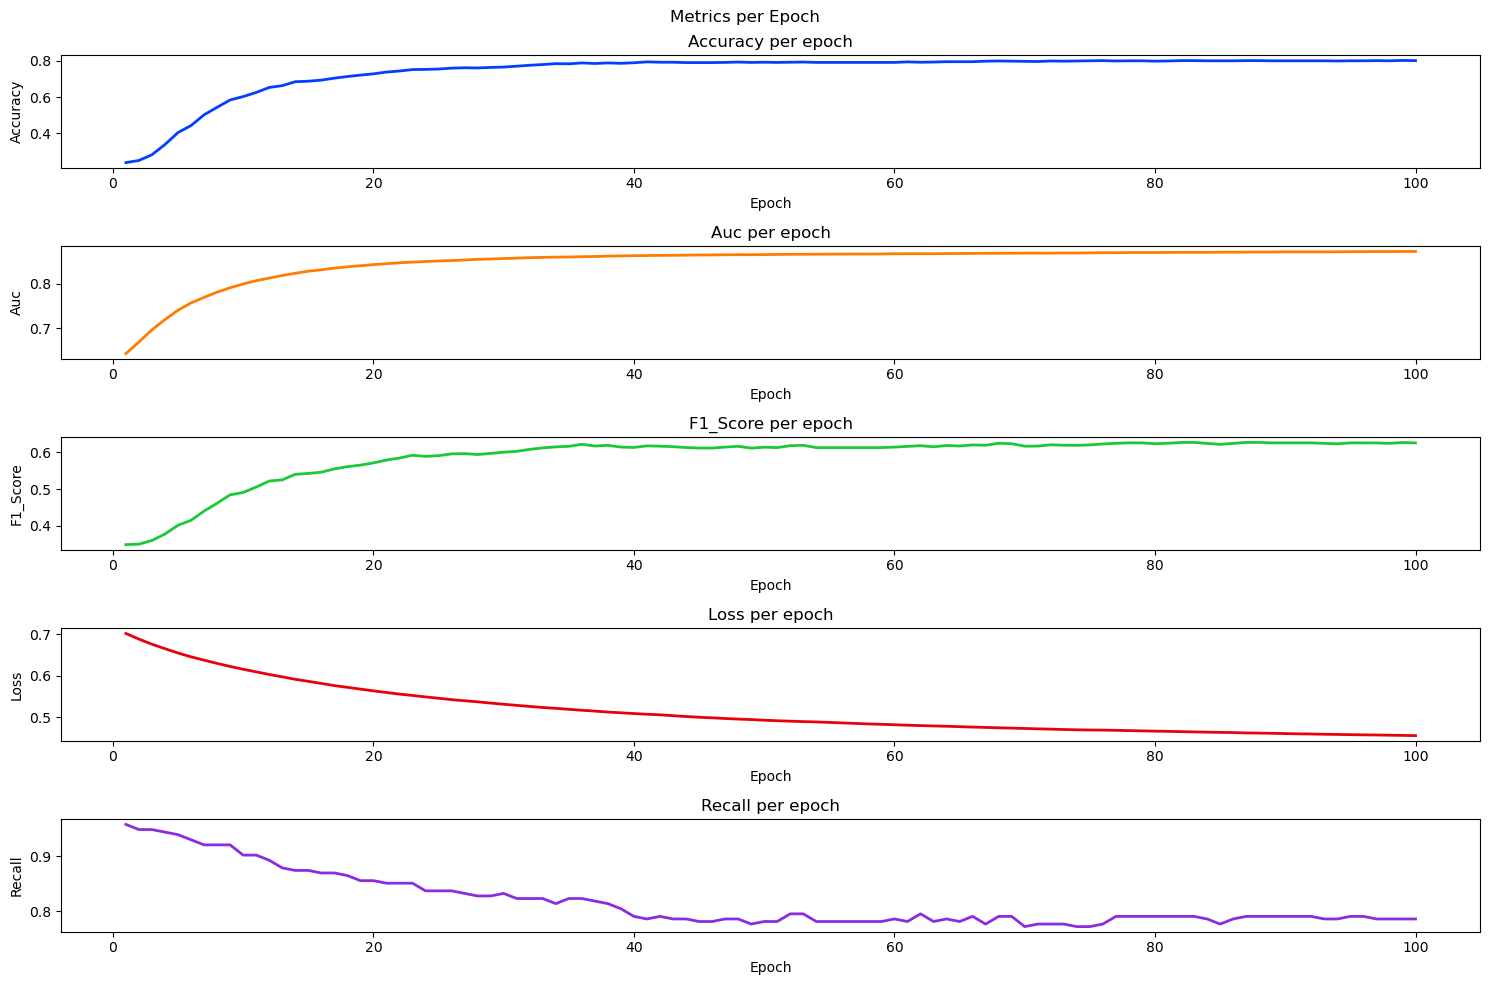

In [14]:
visualize_metrics(baseline_history)

The metrics improve over time as expected

I will now evaluate the model on the train and test set:

In [15]:
# Define a helper function to evaluate a model
def evaluate_model_on_test_and_train(model, X_train=X_train_scaled, y_train=y_train, X_test=X_test_scaled, y_test=y_test):
    print("Train:\n", model.evaluate(X_train, y_train, return_dict=True, verbose=False))
    print("Test:\n", model.evaluate(X_test, y_test, return_dict=True, verbose=False))
    return

evaluate_model_on_test_and_train(baseline_model)

Train:
 {'accuracy': 0.8009852170944214, 'auc': 0.8734215497970581, 'f1_score': 0.6273062229156494, 'loss': 0.4702621102333069, 'recall': 0.7906976938247681}
Test:
 {'accuracy': 0.7701149582862854, 'auc': 0.8209215402603149, 'f1_score': 0.5798318386077881, 'loss': 0.5447466373443604, 'recall': 0.75}


This is a decent performance. I will now apply regularization to see if it improves performance

### a) l1 regularization

I will use an $ \alpha $ of 0.005

In [16]:
l1_model = models.Sequential()

# Add input layer
l1_model.add(layers.Input(input_shape))

# Add hidden layers with l1 regularization applied
l1_model.add(layers.Dense(50, activation='relu', kernel_regularizer=keras.regularizers.l1(0.005)))
l1_model.add(layers.Dense(25, activation='relu', kernel_regularizer=keras.regularizers.l1(0.005)))

# Add output layer
l1_model.add(layers.Dense(1, activation='sigmoid'))

# Train the model
l1_history = compile_and_fit(l1_model)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2355 - auc: 0.6276 - f1_score: 0.3501 - loss: 1.9473 - recall: 0.9721
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2483 - auc: 0.6474 - f1_score: 0.3528 - loss: 1.9387 - recall: 0.9674
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2611 - auc: 0.6686 - f1_score: 0.3568 - loss: 1.9299 - recall: 0.9674
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2749 - auc: 0.6894 - f1_score: 0.3611 - loss: 1.9218 - recall: 0.9674 
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2975 - auc: 0.7034 - f1_score: 0.3662 - loss: 1.9137 - recall: 0.9581
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3143 - auc: 0.7194 - f1_score: 0.3730 - loss: 1.9057 - recall: 0.9628
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3419 - auc: 0.7321 - f1_score: 0.3803 - loss: 1.8987 - recall: 0.9535
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0

Visualizing metric performance:

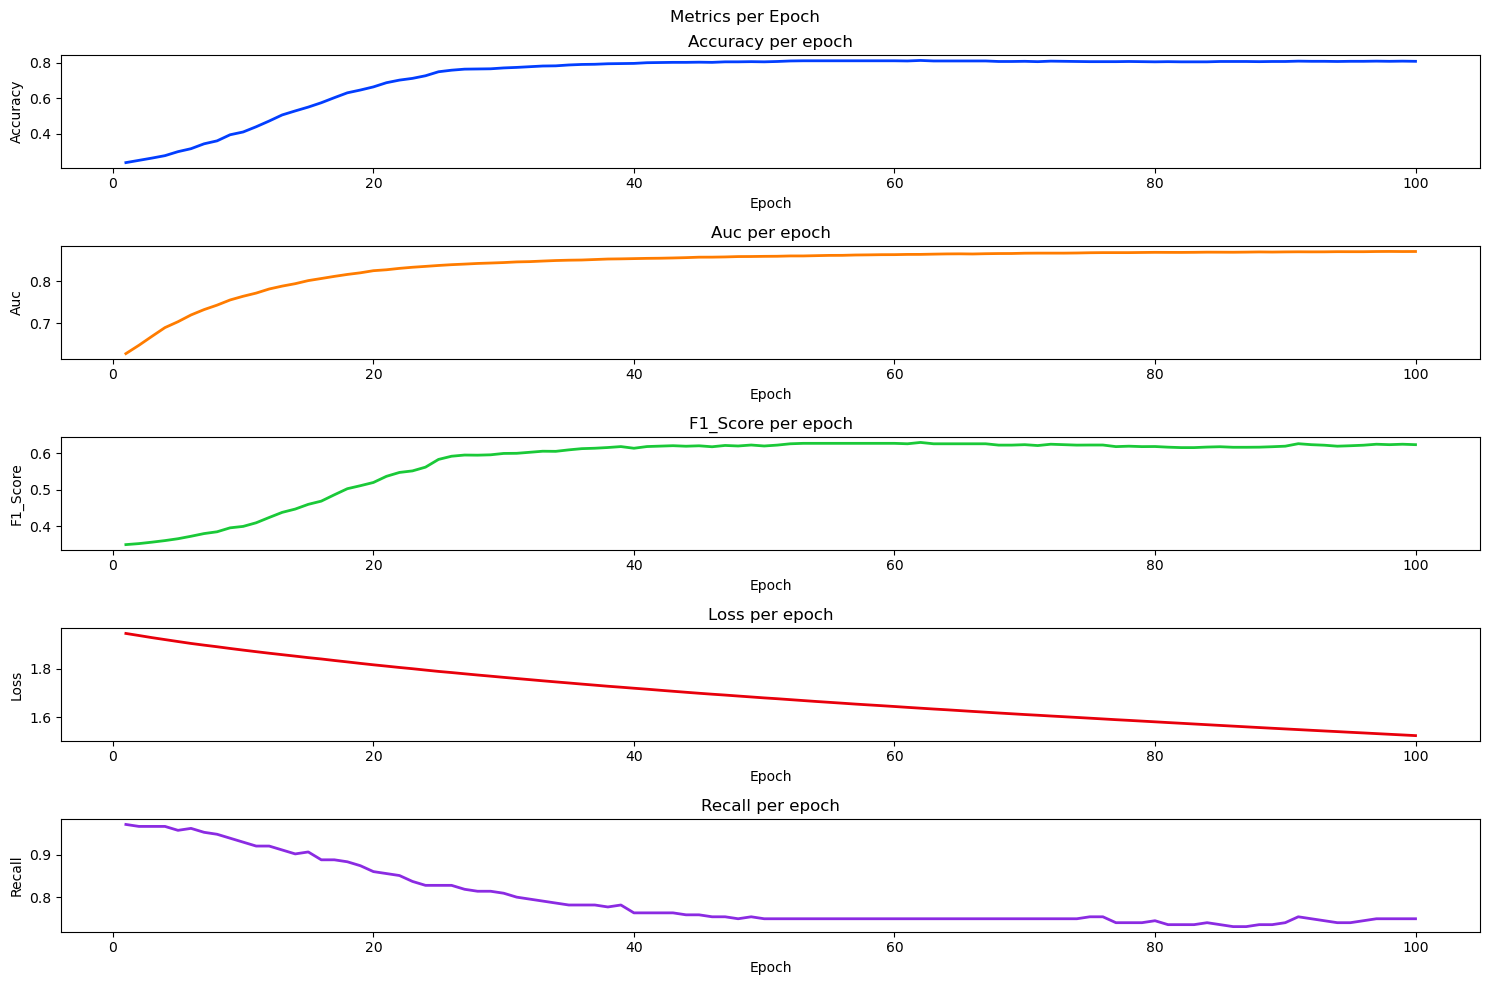

In [17]:
visualize_metrics(l1_history)

The recall appears to be fluctuating.

Evaluating on train and test set:

In [18]:
print("Baseline:")
evaluate_model_on_test_and_train(baseline_model)
print("\n")
print("l1 model:")
evaluate_model_on_test_and_train(l1_model)

Baseline:
Train:
 {'accuracy': 0.8009852170944214, 'auc': 0.8734215497970581, 'f1_score': 0.6273062229156494, 'loss': 0.4702621102333069, 'recall': 0.7906976938247681}
Test:
 {'accuracy': 0.7701149582862854, 'auc': 0.8209215402603149, 'f1_score': 0.5798318386077881, 'loss': 0.5447466373443604, 'recall': 0.75}


l1 model:
Train:
 {'accuracy': 0.8088669776916504, 'auc': 0.870084285736084, 'f1_score': 0.6240309476852417, 'loss': 1.5443994998931885, 'recall': 0.7488372325897217}
Test:
 {'accuracy': 0.7586206793785095, 'auc': 0.8110026717185974, 'f1_score': 0.5374448895454407, 'loss': 1.6156351566314697, 'recall': 0.6630434989929199}


The l1 model appears to have comparable performance to the baseline (except for probably a much lower recall score).

> **NB**: The model comparison might seem different for you. This is because of underlying randomization in the initialisation of the kernel weights.

### b) l2 regularization

In [19]:
l2_model = models.Sequential()

# Add input layer
l2_model.add(layers.Input(input_shape))

# Add hidden layers
l2_model.add(layers.Dense(50, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)))
l2_model.add(layers.Dense(25, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)))

# Add output layer
l2_model.add(layers.Dense(1, activation='sigmoid'))

# Compile and fit the model
l2_history = compile_and_fit(l2_model)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7714 - auc: 0.7182 - f1_score: 0.3012 - loss: 0.9007 - recall: 0.2326
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7813 - auc: 0.7524 - f1_score: 0.4158 - loss: 0.8837 - recall: 0.3674
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7803 - auc: 0.7714 - f1_score: 0.4728 - loss: 0.8718 - recall: 0.4651
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7862 - auc: 0.7866 - f1_score: 0.5252 - loss: 0.8607 - recall: 0.5581
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7754 - auc: 0.7975 - f1_score: 0.5440 - loss: 0.8493 - recall: 0.6326
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7744 - auc: 0.8047 - f1_score: 0.5571 - loss: 0.8426 - recall: 0.6698
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7655 - auc: 0.8120 - f1_score: 0.5576 - loss: 0.8344 - recall: 0.6977
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0

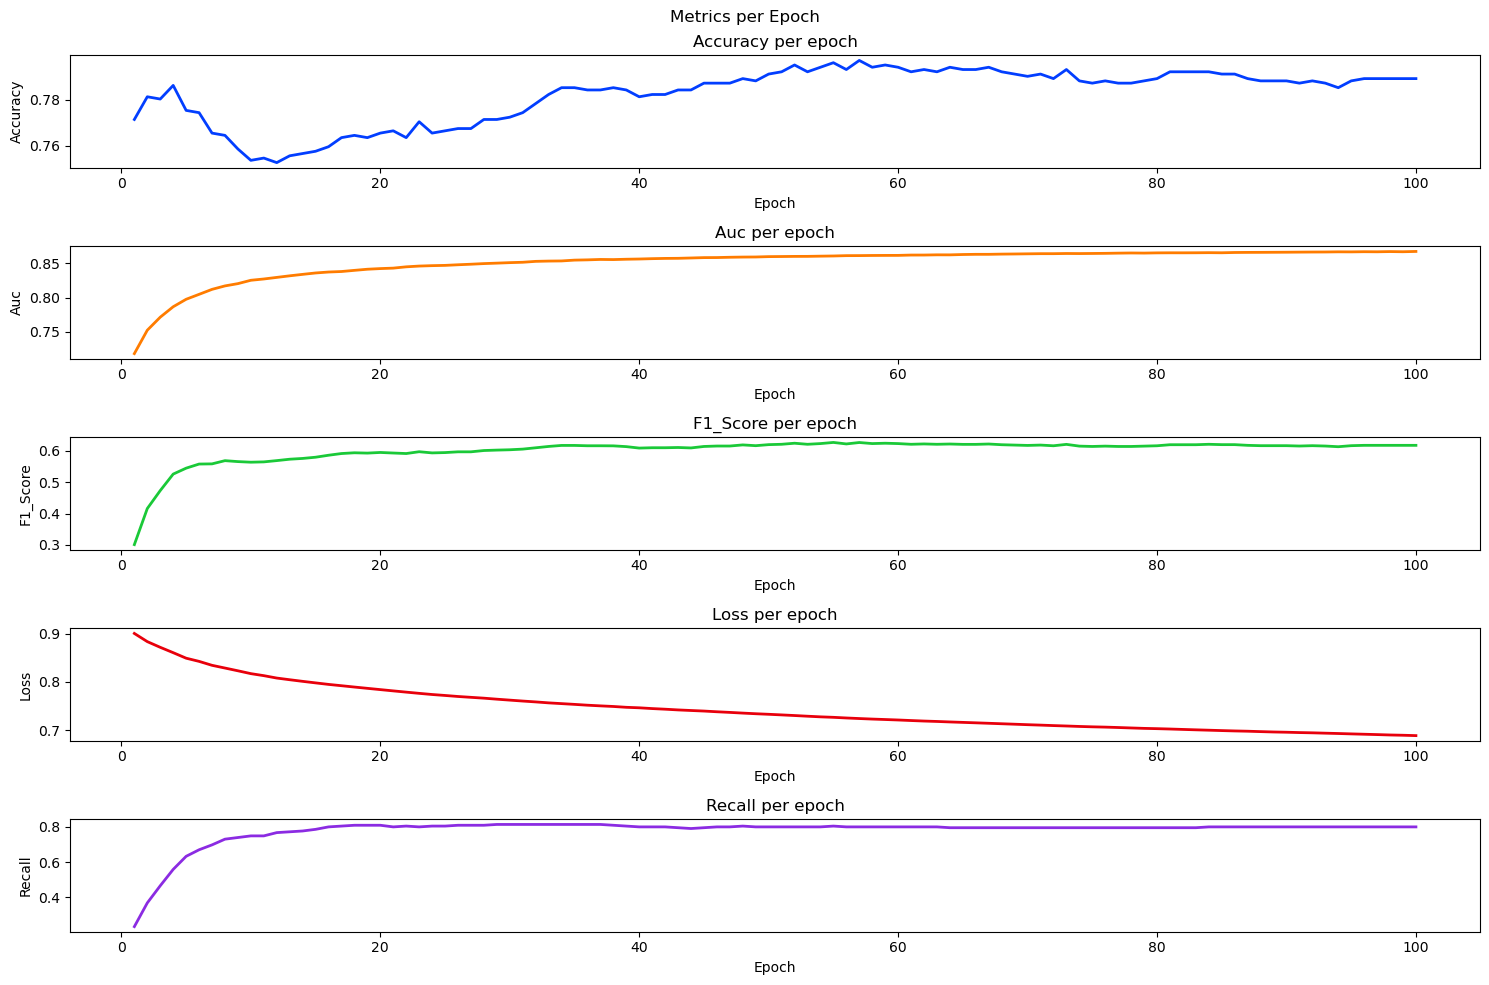

In [20]:
visualize_metrics(l2_history)

In [21]:
print("Baseline:")
evaluate_model_on_test_and_train(baseline_model)
print("\n\n")
print("l1 model:")
evaluate_model_on_test_and_train(l1_model)
print("\n\n")
print("l2 model:")
evaluate_model_on_test_and_train(l2_model)

Baseline:
Train:
 {'accuracy': 0.8009852170944214, 'auc': 0.8734215497970581, 'f1_score': 0.6273062229156494, 'loss': 0.4702621102333069, 'recall': 0.7906976938247681}
Test:
 {'accuracy': 0.7701149582862854, 'auc': 0.8209215402603149, 'f1_score': 0.5798318386077881, 'loss': 0.5447466373443604, 'recall': 0.75}



l1 model:
Train:
 {'accuracy': 0.8088669776916504, 'auc': 0.870084285736084, 'f1_score': 0.6240309476852417, 'loss': 1.5443994998931885, 'recall': 0.7488372325897217}
Test:
 {'accuracy': 0.7586206793785095, 'auc': 0.8110026717185974, 'f1_score': 0.5374448895454407, 'loss': 1.6156351566314697, 'recall': 0.6630434989929199}



l2 model:
Train:
 {'accuracy': 0.7891625761985779, 'auc': 0.8674970865249634, 'f1_score': 0.6178570985794067, 'loss': 0.703395426273346, 'recall': 0.804651141166687}
Test:
 {'accuracy': 0.7655172348022461, 'auc': 0.8242806196212769, 'f1_score': 0.5749999284744263, 'loss': 0.7599907517433167, 'recall': 0.75}


The l2 model has better recall and auc score compared to baseline.

### c) Dropout Regularization

I will use a dropout rate of 0.3

In [22]:
dropout_model = models.Sequential()

# Add input layer
dropout_model.add(layers.Input(input_shape))
## I will not add dropout to the input layer given that the data is not substantive

# Add hidden layers and include dropout. Use a seed for reproducibility
dropout_model.add(layers.Dense(50, activation='relu'))
dropout_model.add(layers.Dropout(0.3, seed=2026))
dropout_model.add(layers.Dense(25, activation='relu'))
dropout_model.add(layers.Dropout(0.3, seed=2026))

# Add output layer
dropout_model.add(layers.Dense(1, activation='sigmoid'))

# Compile and fit the model
dropout_history = compile_and_fit(dropout_model)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3458 - auc: 0.4743 - f1_score: 0.3293 - loss: 0.7753 - recall: 0.7581
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3616 - auc: 0.5569 - f1_score: 0.3468 - loss: 0.7368 - recall: 0.8000
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3754 - auc: 0.5998 - f1_score: 0.3517 - loss: 0.7180 - recall: 0.8000
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3813 - auc: 0.5955 - f1_score: 0.3499 - loss: 0.7083 - recall: 0.7860
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4059 - auc: 0.6036 - f1_score: 0.3712 - loss: 0.7060 - recall: 0.8279
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4197 - auc: 0.6200 - f1_score: 0.3660 - loss: 0.6930 - recall: 0.7907
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4463 - auc: 0.6268 - f1_score: 0.3811 - loss: 0.6935 - recall: 0.8047
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 

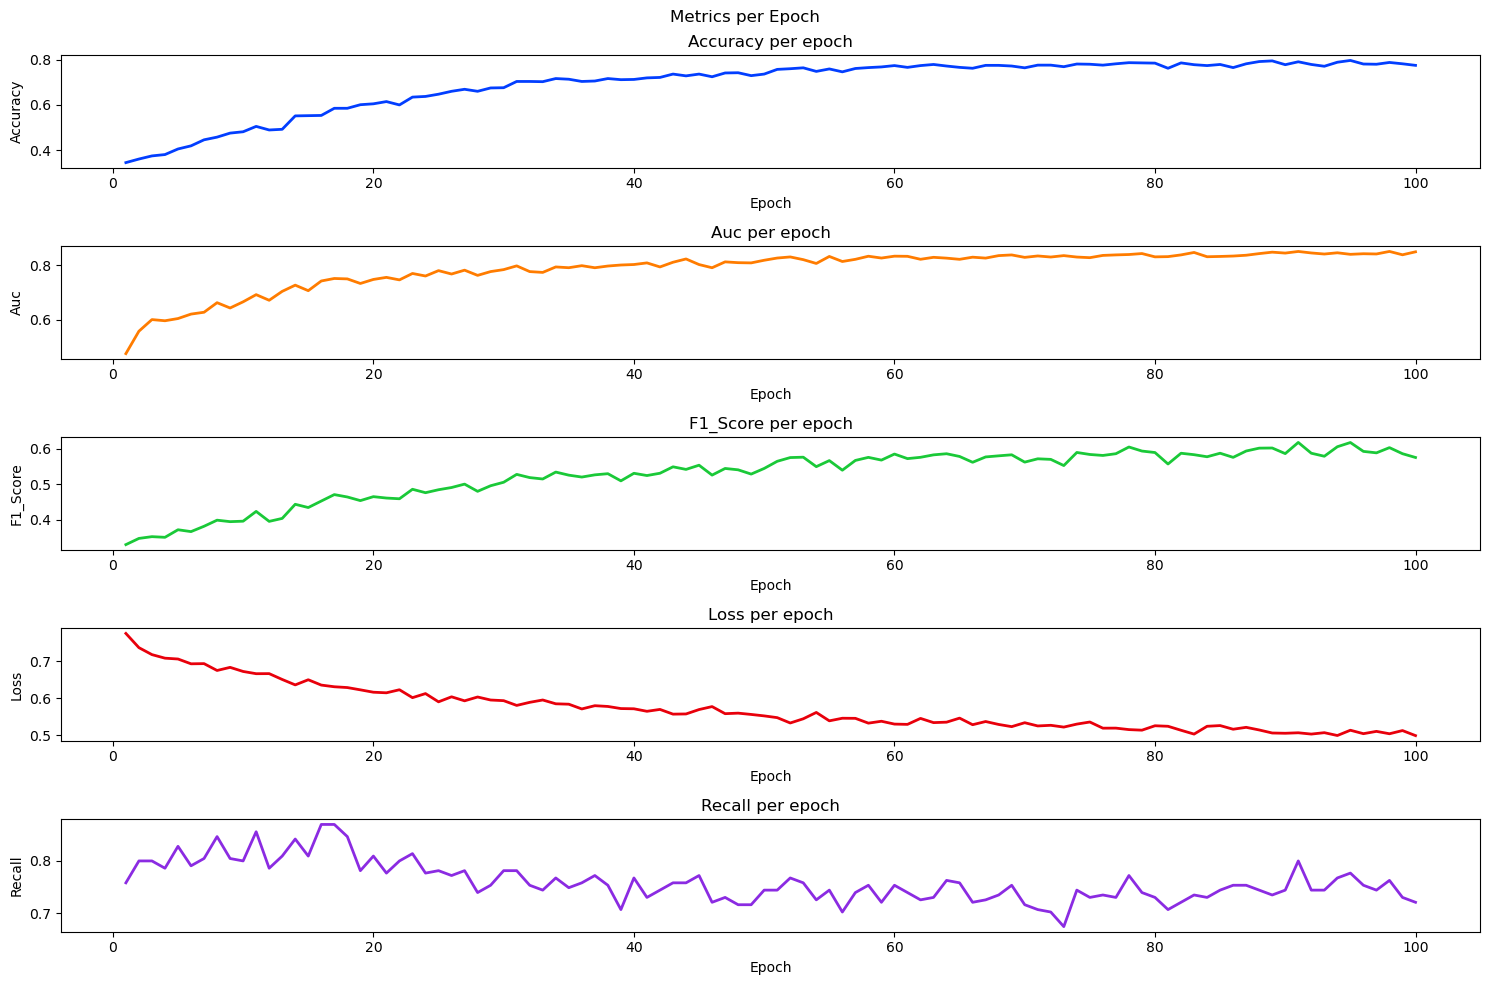

In [23]:
visualize_metrics(dropout_history)

There is a step-wise improvement in the metrics.

In [24]:
print("Baseline:")
evaluate_model_on_test_and_train(baseline_model)
print("\n\n")
print("l1 model:")
evaluate_model_on_test_and_train(l1_model)
print("\n\n")
print("l2 model:")
evaluate_model_on_test_and_train(l2_model)
print("\n\n")
print("Dropout model:")
evaluate_model_on_test_and_train(dropout_model)

Baseline:
Train:
 {'accuracy': 0.8009852170944214, 'auc': 0.8734215497970581, 'f1_score': 0.6273062229156494, 'loss': 0.4702621102333069, 'recall': 0.7906976938247681}
Test:
 {'accuracy': 0.7701149582862854, 'auc': 0.8209215402603149, 'f1_score': 0.5798318386077881, 'loss': 0.5447466373443604, 'recall': 0.75}



l1 model:
Train:
 {'accuracy': 0.8088669776916504, 'auc': 0.870084285736084, 'f1_score': 0.6240309476852417, 'loss': 1.5443994998931885, 'recall': 0.7488372325897217}
Test:
 {'accuracy': 0.7586206793785095, 'auc': 0.8110026717185974, 'f1_score': 0.5374448895454407, 'loss': 1.6156351566314697, 'recall': 0.6630434989929199}



l2 model:
Train:
 {'accuracy': 0.7891625761985779, 'auc': 0.8674970865249634, 'f1_score': 0.6178570985794067, 'loss': 0.703395426273346, 'recall': 0.804651141166687}
Test:
 {'accuracy': 0.7655172348022461, 'auc': 0.8242806196212769, 'f1_score': 0.5749999284744263, 'loss': 0.7599907517433167, 'recall': 0.75}



Dropout model:
Train:
 {'accuracy': 0.811822652

The dropout model has better recall compared to the baseline model. It's performance is comparable to the l2 model, although it exhibits a much better loss metric.

Finally, I will implement early stopping to the baseline model

### d) Early Stopping

I will stop minimizing the loss a.k.a stop gradient descent once the f1_score stops improving

In [25]:
from keras.callbacks import EarlyStopping

callback = EarlyStopping(
    monitor='f1_score',
    mode='max',
    restore_best_weights=True,
    patience=5
)

early_stopping_model = models.Sequential()

# Add input layer
early_stopping_model.add(layers.Input(input_shape))

# Add hidden layers
early_stopping_model.add(layers.Dense(50, activation='relu'))
early_stopping_model.add(layers.Dense(25, activation='relu'))

# Add output layer
early_stopping_model.add(layers.Dense(1, activation='sigmoid'))

# Compile and fit the model
early_stopping_history = compile_and_fit(early_stopping_model, early_stopping=True, callbacks=[callback])

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6404 - auc: 0.7459 - f1_score: 0.4624 - loss: 0.6300 - recall: 0.7302
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6650 - auc: 0.7655 - f1_score: 0.4880 - loss: 0.6190 - recall: 0.7535
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6719 - auc: 0.7821 - f1_score: 0.4947 - loss: 0.6079 - recall: 0.7581
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6867 - auc: 0.7964 - f1_score: 0.5152 - loss: 0.5974 - recall: 0.7860
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6966 - auc: 0.8043 - f1_score: 0.5187 - loss: 0.5898 - recall: 0.7721
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7113 - auc: 0.8116 - f1_score: 0.5312 - loss: 0.5823 - recall: 0.7721
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7222 - auc: 0.8179 - f1_score: 0.5437 - loss: 0.5755 - recall: 0.7814
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 

The f1-score stopped increasing at epoch 40 (might be different for you)

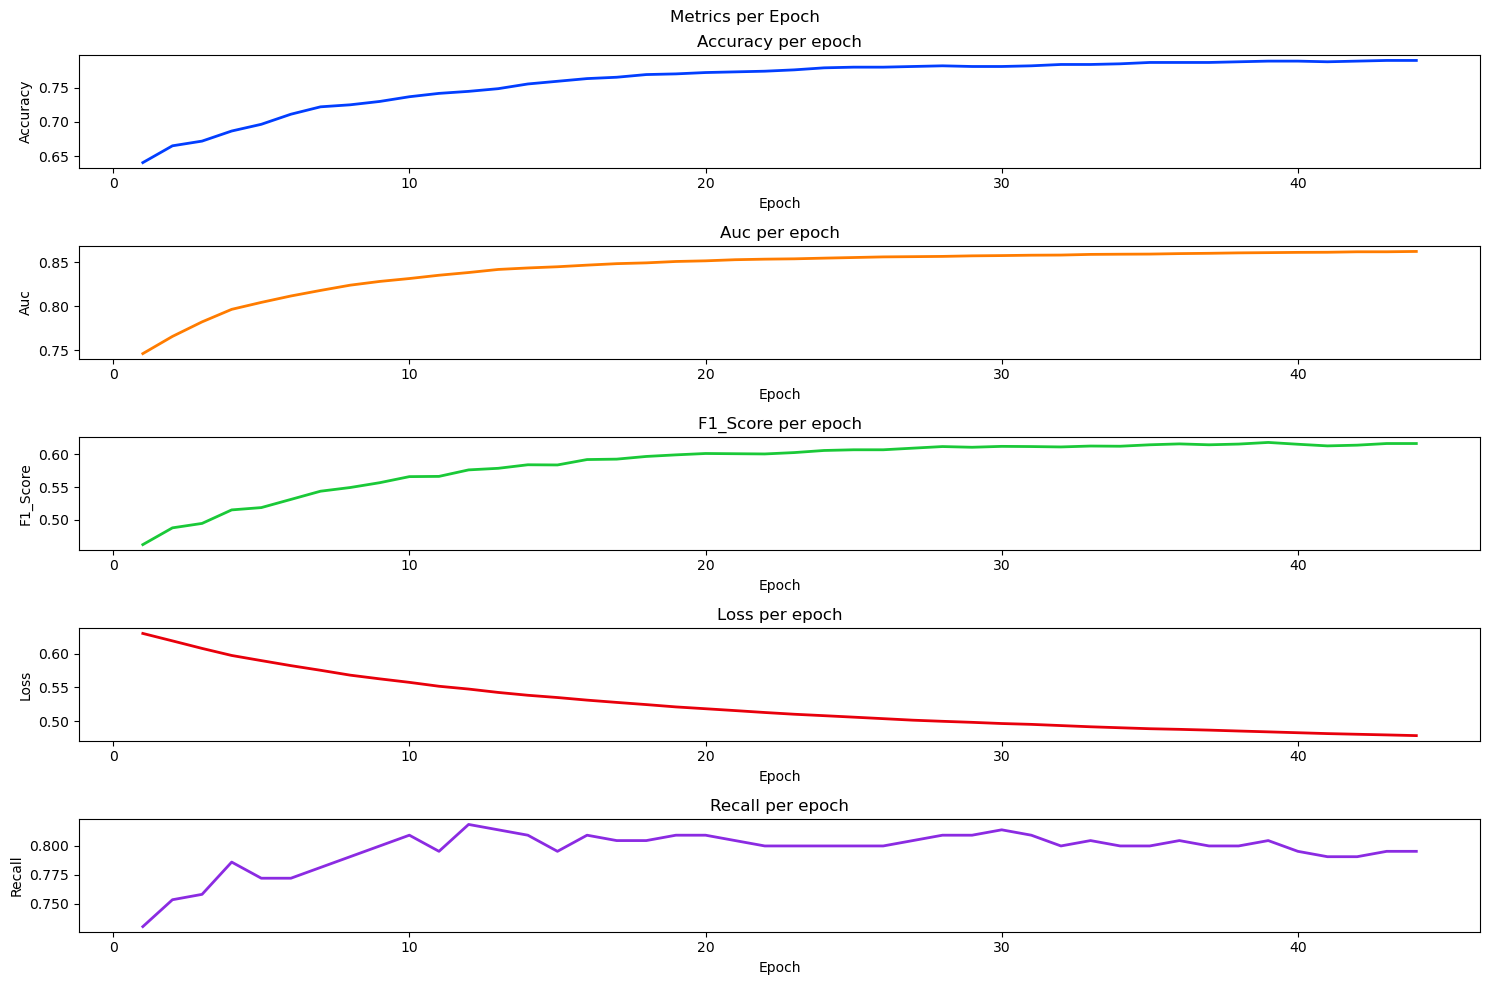

In [26]:
visualize_metrics(early_stopping_history)

## 5. Final Evaluation

In [27]:
print("Baseline:")
evaluate_model_on_test_and_train(baseline_model)
print("\n")
print("l1 model:")
evaluate_model_on_test_and_train(l1_model)
print("\n")
print("l2 model:")
evaluate_model_on_test_and_train(l2_model)
print("\n")
print("Dropout model:")
evaluate_model_on_test_and_train(dropout_model)
print("\n")
print("Callback model:")
evaluate_model_on_test_and_train(early_stopping_model)

Baseline:
Train:
 {'accuracy': 0.8009852170944214, 'auc': 0.8734215497970581, 'f1_score': 0.6273062229156494, 'loss': 0.4702621102333069, 'recall': 0.7906976938247681}
Test:
 {'accuracy': 0.7701149582862854, 'auc': 0.8209215402603149, 'f1_score': 0.5798318386077881, 'loss': 0.5447466373443604, 'recall': 0.75}


l1 model:
Train:
 {'accuracy': 0.8088669776916504, 'auc': 0.870084285736084, 'f1_score': 0.6240309476852417, 'loss': 1.5443994998931885, 'recall': 0.7488372325897217}
Test:
 {'accuracy': 0.7586206793785095, 'auc': 0.8110026717185974, 'f1_score': 0.5374448895454407, 'loss': 1.6156351566314697, 'recall': 0.6630434989929199}


l2 model:
Train:
 {'accuracy': 0.7891625761985779, 'auc': 0.8674970865249634, 'f1_score': 0.6178570985794067, 'loss': 0.703395426273346, 'recall': 0.804651141166687}
Test:
 {'accuracy': 0.7655172348022461, 'auc': 0.8242806196212769, 'f1_score': 0.5749999284744263, 'loss': 0.7599907517433167, 'recall': 0.75}


Dropout model:
Train:
 {'accuracy': 0.811822652816

## 6. Conclusion

The best all-round model is the **l2 model**. This is the model I shall use as the best neural network.

> **NB**: The best model for you might seem different. This is because of underlying randomization in the initialisation of the kernel weights. However, after running the notebook multiple times, I found the model that performed the best consistently to be the l2 model.

In [28]:
l2_model.save('../best_neural_model.keras')